In [1]:
# Load Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
# Load Dataset
df = pd.read_csv('multiple_regression_analysis.csv')

df.head()

,TV,Radio,Social Media,Influencer,Sales
0,Low,3.518070,2.293790,Micro,55.261284
1,Low,7.756876,2.572287,Mega,67.574904
2,High,20.348988,1.227180,Micro,272.250108
3,Medium,20.108487,2.728374,Mega,195.102176
4,High,31.653200,7.776978,Nano,273.960377


In [3]:
# Data Cleaning & Standardization
# Fix column naming issues
df.columns = df.columns.str.replace(" ", "_")
df.columns

Index(['TV', 'Radio', 'Social_Media', 'Influencer', 'Sales'], dtype='object')

In [4]:
# Check Data Types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 572 entries, 0 to 571
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            572 non-null    object 
 1   Radio         572 non-null    float64
 2   Social_Media  572 non-null    float64
 3   Influencer    572 non-null    object 
 4   Sales         572 non-null    float64
dtypes: float64(3), object(2)
memory usage: 22.5+ KB


In [5]:
# Missing Values Check
df.isnull().sum()

TV              0
Radio           0
Social_Media    0
Influencer      0
Sales           0
dtype: int64

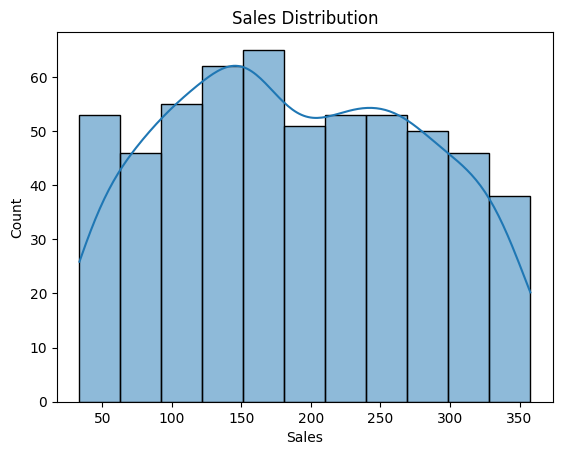

In [6]:
# Exploratory Data Analysis (EDA)
# Sales Distribution
sns.histplot(df["Sales"], 
             kde=True) 
plt.title("Sales Distribution") 
plt.show()

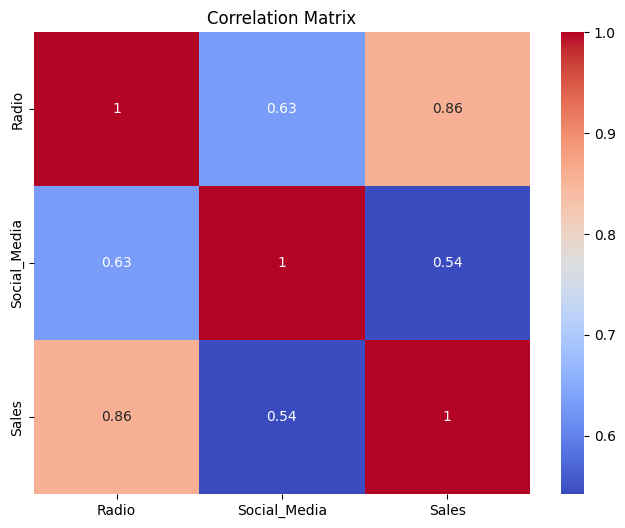

In [7]:
# Correlation Matrix
plt.figure(figsize=(8,6)) 
sns.heatmap(df.corr(numeric_only=True), 
            annot=True, 
            cmap="coolwarm") 
plt.title("Correlation Matrix") 
plt.show()

In [8]:
# Convert categorical variables (Encoding)
df_encoded = pd.get_dummies( 
    df, columns=["TV", "Influencer"], 
    drop_first=True
) 
df_encoded = df_encoded.astype(float) 
df_encoded.head()

,Radio,Social_Media,Sales,TV_Low,TV_Medium,Influencer_Mega,Influencer_Micro,Influencer_Nano
0,3.518070,2.293790,55.261284,1.0,0.0,0.0,1.0,0.0
1,7.756876,2.572287,67.574904,1.0,0.0,1.0,0.0,0.0
2,20.348988,1.227180,272.250108,0.0,0.0,0.0,1.0,0.0
3,20.108487,2.728374,195.102176,0.0,1.0,1.0,0.0,0.0
4,31.653200,7.776978,273.960377,0.0,0.0,0.0,0.0,1.0


In [9]:
# Multicollinearity Check (VIF)
X_vif = df_encoded.drop("Sales", axis=1) 
X_vif = sm.add_constant(X_vif) 
vif = pd.DataFrame() 
vif["Variable"] = X_vif.columns 
vif["VIF"] = [ 
    variance_inflation_factor(X_vif.values, i) 
    for i in range(X_vif.shape[1]) 
] 

vif.sort_values("VIF", ascending=False)

,Variable,VIF
0,const,31.649565
3,TV_Low,4.076384
1,Radio,3.479641
4,TV_Medium,2.233350
2,Social_Media,1.669098
7,Influencer_Nano,1.627430
6,Influencer_Micro,1.618434
5,Influencer_Mega,1.593889


In [10]:
# Model Development (OLS Regression) 
X = df_encoded.drop("Sales", axis=1) 
y = df_encoded["Sales"] 

X = sm.add_constant(X) 

model = sm.OLS(y, X).fit() 

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.904
Model:                            OLS   Adj. R-squared:                  0.903
Method:                 Least Squares   F-statistic:                     760.4
Date:                Tue, 09 Jun 2026   Prob (F-statistic):          1.82e-282
Time:                        18:45:09   Log-Likelihood:                -2713.4
No. Observations:                 572   AIC:                             5443.
Df Residuals:                     564   BIC:                             5478.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              217.4784      6.584  

In [13]:
# Residual Diagnostics
# Predicions & Residuals
predictions = model.predict(X)
residuals = y - predictions


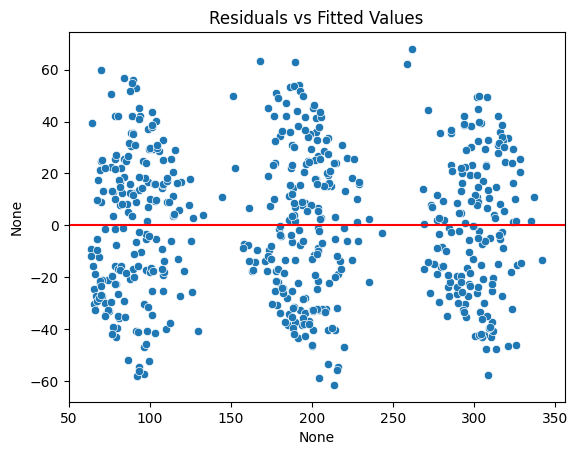

In [14]:
# Residual vs Fitted Values
sns.scatterplot(x=predictions, y=residuals) 
plt.axhline(0, color="red") 
plt.title("Residuals vs Fitted Values") 
plt.show()

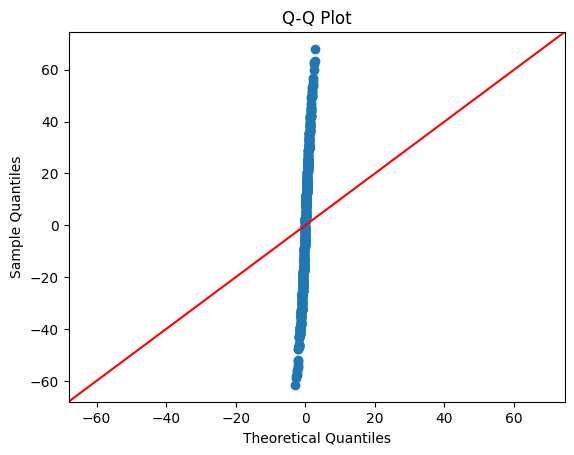

In [15]:
# Q-Q Plot
sm.qqplot(residuals, line="45") 
plt.title("Q-Q Plot") 
plt.show()

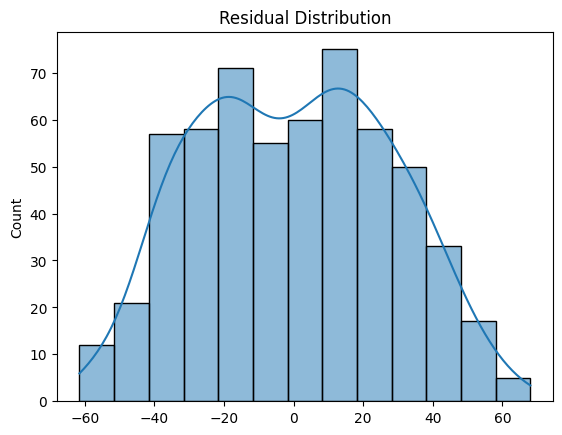

In [16]:
# Residual Distribution
sns.histplot(residuals, kde=True) 
plt.title("Residual Distribution") 
plt.show()